# 📊 EDA for Data Visualization – Gapminder Dataset

## ✨ Introduction
Welcome to your first hands-on notebook for **Exploratory Data Analysis (EDA)** using visualizations. In this notebook, we’ll work with the Gapminder dataset to:

- Explore the structure and content of the dataset
- Understand distributions, trends, and relationships between variables
- Use visualizations to tell a data story
- Practice using **matplotlib** and **seaborn** for plotting

EDA is a key step in any data science project—this is where insights start to emerge!

### 🗂️ About the Dataset
The Gapminder dataset provides socio-economic indicators over time across countries and continents. The version we are using contains the following columns:

- `country`: Name of the country
- `continent`: The continent the country belongs to
- `year`: The year the data was recorded
- `life_exp`: Life expectancy in years
- `hdi_index`: Human Development Index (scale from 0 to 1)
- `co2_consump`: CO₂ consumption per capita
- `gdp`: Gross Domestic Product per capita
- `services`: Percentage of GDP spent on services

These variables will help us understand development trends and disparities across the globe.

---
## 📦 1. Import Required Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 🌍 2. Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv("../data/gapminder_data_graphs.csv")

## 🕵️‍♀️ 3. Explore the Dataset

In [3]:
# First few rows
df.head()

,country,continent,year,life_exp,hdi_index,co2_consump,gdp,services
0,Afghanistan,Asia,1998,53.3,0.344,0.0522,NaN,24.4
1,Afghanistan,Asia,1999,54.7,0.348,0.0402,NaN,24.6
2,Afghanistan,Asia,2000,54.7,0.350,0.0370,NaN,24.7
3,Afghanistan,Asia,2001,54.8,0.353,0.0376,NaN,24.7
4,Afghanistan,Asia,2002,55.5,0.384,0.0471,333.0,25.6


This gives us a snapshot of the dataset. We can see that each row represents a country's data for a specific year, including economic, environmental, and development indicators.


In [4]:
# Structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3675 entries, 0 to 3674
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      3675 non-null   object 
 1   continent    3675 non-null   object 
 2   year         3675 non-null   int64  
 3   life_exp     3675 non-null   float64
 4   hdi_index    3563 non-null   float64
 5   co2_consump  3671 non-null   float64
 6   gdp          3633 non-null   float64
 7   services     3675 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 229.8+ KB


This tells us the data types and confirms there are no missing values in our main features.
- The dataset contains **3,675 rows** and **8 columns**.
- Most variables are floats; `country` and `continent` are categorical, and `year` is an integer.
- There are a few missing values in `hdi_index` (112), `co2_consump` (4), and `gdp` (42).

In [5]:
# Statistical summary
df.describe()

,year,life_exp,hdi_index,co2_consump,gdp,services
count,3675.000000,3675.000000,3563.000000,3671.000000,3633.000000,3675.000000
mean,2008.000000,69.849306,0.674864,4.712731,11966.053675,51.248705
std,6.056125,8.886563,0.164834,6.567435,17105.787953,18.312501
min,1998.000000,32.500000,0.255000,0.015900,238.000000,5.590000
25%,2003.000000,63.900000,0.537500,0.560500,1470.000000,37.600000
50%,2008.000000,71.700000,0.699000,2.250000,4280.000000,52.900000
75%,2013.000000,76.400000,0.805000,6.615000,13600.000000,65.700000
max,2018.000000,84.800000,0.956000,67.100000,105000.000000,88.500000


This provides insight into the range and distribution of numeric features:
- Life expectancy ranges from **32.5** to **84.8** years.
- GDP ranges from **238** to **105,000**, showing a highly skewed distribution.
- CO₂ consumption and HDI also vary widely between countries.

In [6]:
# Check for missing values
df.isnull().sum()

country          0
continent        0
year             0
life_exp         0
hdi_index      112
co2_consump      4
gdp             42
services         0
dtype: int64

Only a few columns have missing data:
- `hdi_index`: 112 missing (can consider imputation or analysis excluding this column)
- `gdp`: 42 missing (may impact GDP-based analysis)
- `co2_consump`: 4 missing (minimal impact)

🔍 For future analysis, we’ll either exclude rows with missing data or handle them explicitly depending on the plot requirements.
> For this notebook we'll remove missing data using `.dropna()` if needed

---

## 🔹 4. Univariate Analysis
**Objective:** Understand how individual variables are distributed and where potential outliers exist.

### 📊 Histogram of GDP per Capita

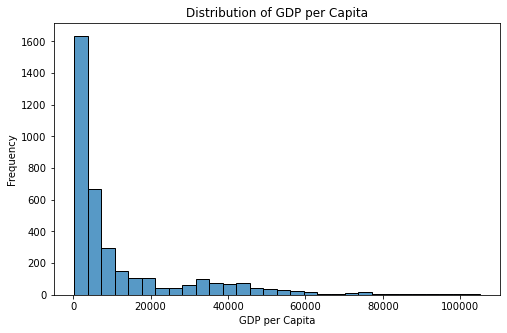

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['gdp'], bins=30, kde=False)
plt.title("Distribution of GDP per Capita")
plt.xlabel("GDP per Capita")
plt.ylabel("Frequency")
plt.show()

**🔍 Insight:** The histogram shows a highly right-skewed distribution. The vast majority of countries have a GDP below 20,000, with only a few outliers above 50,000. 

This highlights global economic inequality, where wealth is concentrated in a small number of countries.

### 📈 KDE Plot of Life Expectancy

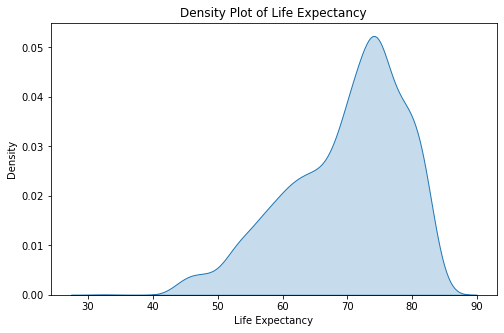

In [8]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df['life_exp'], fill=True)
plt.title("Density Plot of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.show()

**🔍 Insight:** Life expectancy is fairly normally distributed with a slight right skew. Most countries fall between 60 and 80 years, with a peak around 72–75 years. 

This indicates general global improvement in health and longevity.

A few countries fall significantly below, possibly due to conflict or lack of healthcare infrastructure.

### 📦 Boxplot of Life Expectancy by Continent

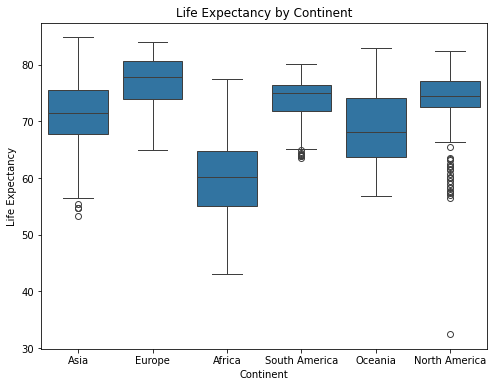

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='continent', y='life_exp', data=df)
plt.title("Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Life Expectancy")
plt.show()

**🔍 Insight:** Africa has the lowest median life expectancy with a large interquartile range. North America shows many outliers. Europe has the highest and most consistent life expectancy. 

This shows disparities in health outcomes by region.

---

## 🔹 5. Bivariate Analysis

**Objective:** Analyze how two variables relate—visually assessing patterns and comparisons.

### ⚫ Scatterplot: GDP vs Life Expectancy

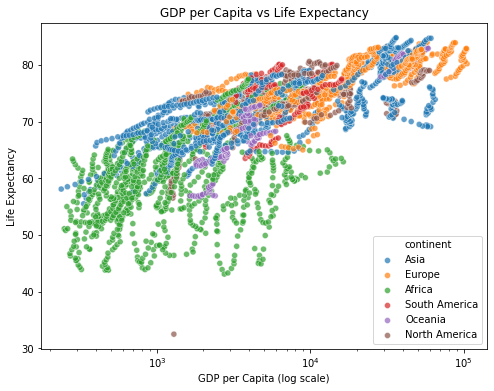

In [10]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='gdp', y='life_exp', hue='continent', alpha=0.7)
plt.xscale('log')
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita (log scale)")
plt.ylabel("Life Expectancy")
plt.show()

**🔍 Insight:** 
- There's a clear positive correlation: higher GDP often aligns with higher life expectancy.

- The relationship levels off—wealthy countries don’t gain much in life expectancy beyond a certain GDP.

- Africa clusters in the bottom left (low GDP, low life expectancy), reinforcing economic and health gaps.

### 📊 Barplot: Average Life Expectancy by Continent

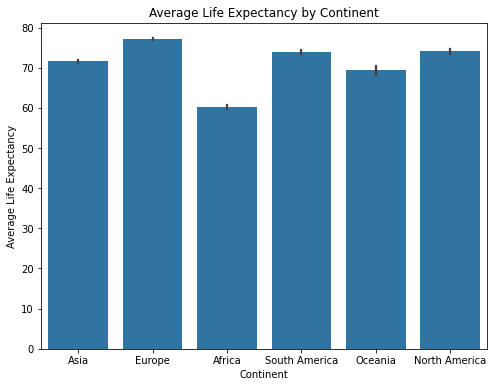

In [11]:
plt.figure(figsize=(8, 6))
sns.barplot(x='continent', y='life_exp', data=df)
plt.title("Average Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")
plt.show()

**🔍 Insight:** Europe has the highest average life expectancy, followed by North America, South America and Asia. Africa has the lowest, reaffirming global disparities in healthcare and development.

This barplot offers a clean visual comparison and supports the boxplot's narrative of regional differences.

---

## 🔹 6. Time Trend Analysis

**Objective:** Identify changes and patterns in life expectancy over time by continent.

### 📈 Life Expectancy Over Time by Continent

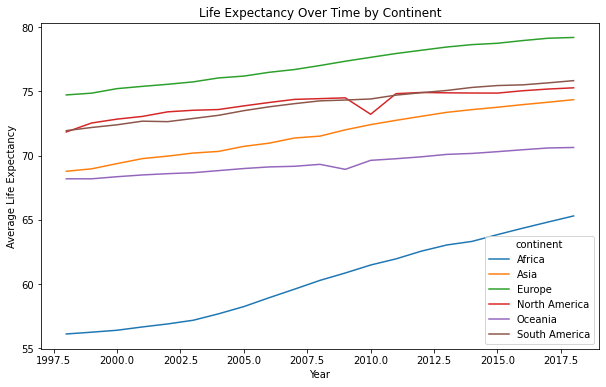

In [12]:
df_grouped = df.groupby(['year', 'continent'])['life_exp'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_grouped, x='year', y='life_exp', hue='continent')
plt.title("Life Expectancy Over Time by Continent")
plt.xlabel("Year")
plt.ylabel("Average Life Expectancy")
plt.show()

**🔍 Insight:** All continents show improvement over time. Africa started lowest but has made the fastest progress. Europe consistently maintains the highest life expectancy. There's a small dip in North America and Ocean around 2010, which could be explored further.

---

## 🔹 7. Bonus: Multivariate Analysis

**Objective:** Explore relationships among multiple numerical variables at once.

### 🔗 Pairplot

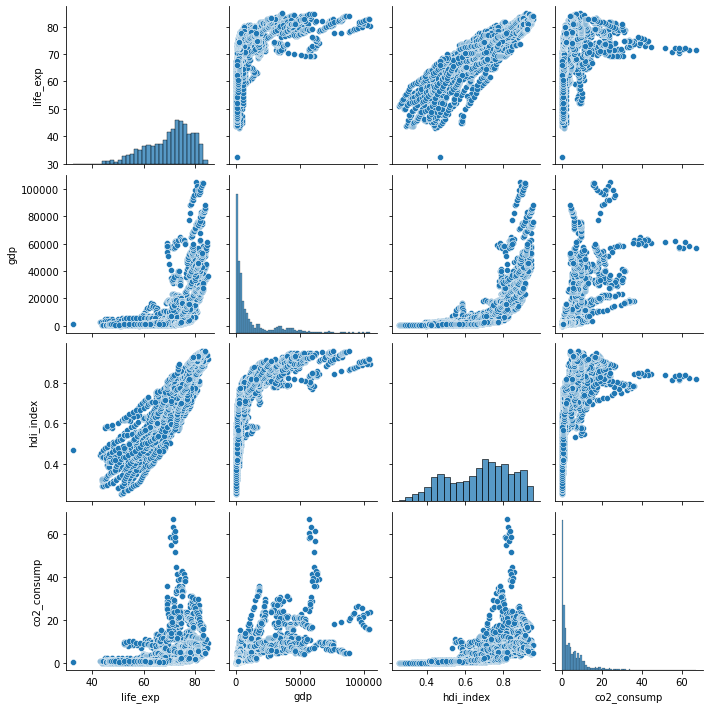

In [13]:
sns.pairplot(df[['life_exp', 'gdp', 'hdi_index', 'co2_consump']])
plt.show()

**🔍 Insight:** 

Strong linear correlation between life expectancy and HDI, and between HDI and GDP.

GDP also correlates moderately with CO₂ consumption, showing development is tied to emissions.

This plot helps uncover multi-variable relationships at a glance.

### 🌡️ Heatmap

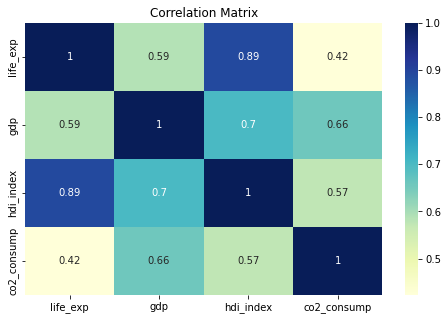

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[['life_exp', 'gdp', 'hdi_index', 'co2_consump']].corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Matrix")
plt.show()

**🔍 Insight:** 

Life Expectancy has strong positive correlation with HDI (0.89) and a moderate correlation with the GDP (0.59).

GDP and HDI also correlate well (0.70).

CO₂ consumption is moderately correlated with all three, especially GDP (0.66).

These values confirm that wealth and development metrics are strongly interconnected.

---

## 🔹 8. Mini Dashboard – Combined View

**Objective:** Summarize insights using a set of complementary plots.

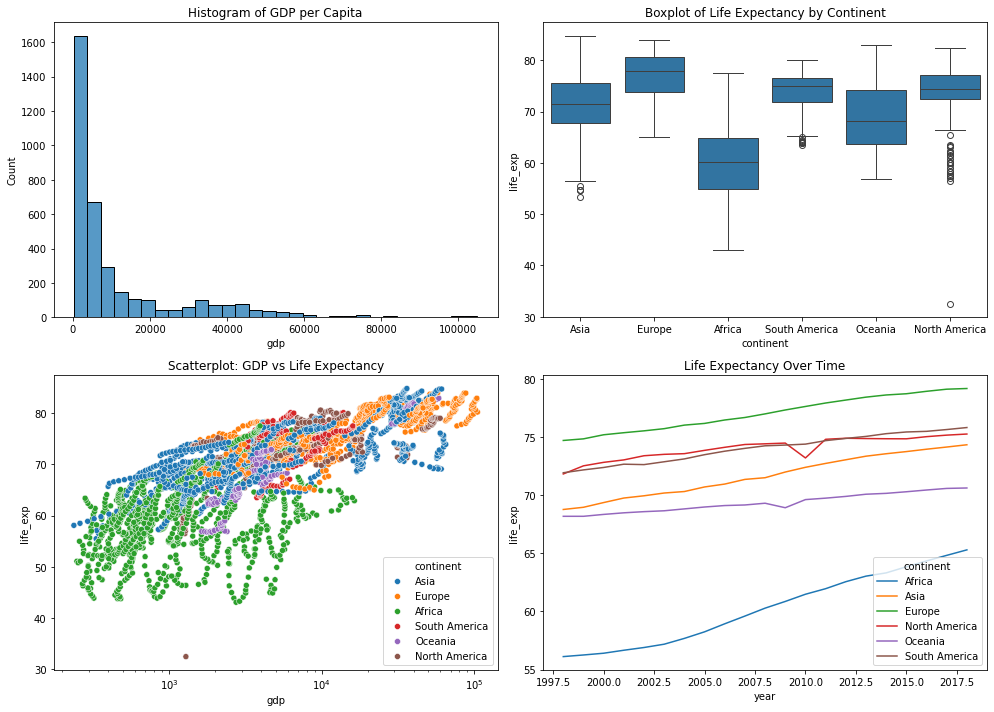

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(data=df, x="gdp", ax=ax[0,0], bins=30)
ax[0,0].set_title("Histogram of GDP per Capita")
sns.boxplot(x="continent", y="life_exp", data=df, ax=ax[0,1])
ax[0,1].set_title("Boxplot of Life Expectancy by Continent")
sns.scatterplot(x="gdp", y="life_exp", data=df, hue="continent", ax=ax[1,0])
ax[1,0].set_xscale('log')
ax[1,0].set_title("Scatterplot: GDP vs Life Expectancy")
df_grouped = df.groupby(['year', 'continent'])['life_exp'].mean().reset_index()
sns.lineplot(data=df_grouped, x='year', y='life_exp', hue='continent', ax=ax[1,1])
ax[1,1].set_title("Life Expectancy Over Time")
plt.tight_layout()
plt.show()

**📊 Dashboard Summary:** This dashboard provides a well-rounded overview of economic and health indicators across time and regions. We see inequality in GDP distribution, visual differences in life expectancy across continents, and overall global improvement over time.

---

## 📌 Summary: What We Learned
✅ We explored a real-world dataset using Python visualizations  
✅ We used **matplotlib** and **seaborn** to generate insightful charts  
✅ We interpreted distributions, trends, and relationships visually  
✅ We learned how to combine multiple visuals into a cohesive data story  

🎯 This hands-on practice gave us a strong foundation in exploratory data analysis and visualization.

Great work exploring, experimenting, and interpreting real data!

---